In [6]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import scipy as sp 
from sklearn.linear_model import LinearRegression

### Loading Data

In [7]:
df_bike_counts = pd.read_csv('bike_project_data/bike_counts.csv', sep=',', names=["datetime","station","latitude","longitude","bike_count"], header=0)
df_holidays = pd.read_csv('bike_project_data/danish_holidays.csv', sep=',', names=["date","holiday"], header=0)
df_stations = pd.read_csv('bike_project_data/stations.csv', sep=',', names=["station","latitude","longitude","daily_avg_2021"], header=0)
df_weather = pd.read_csv('bike_project_data/weather_copenhagen.csv', sep=',', names=["datetime","temperature_C","wind_speed_ms","precipitation_mm"], header=0)

In [8]:
station = df_bike_counts["station"]
bike_count = df_bike_counts["bike_count"]
datetime = pd.to_datetime(df_bike_counts["datetime"])

year, month, day, hour, day_name = datetime.dt.year, datetime.dt.month, datetime.dt.day, datetime.dt.hour, datetime.dt.day_name

### Spliting Data - Langebro Station

In [21]:
Station = "Langebro"

df_bike_counts["datetime"] = pd.to_datetime(df_bike_counts["datetime"])
df_weather["datetime"] = pd.to_datetime(df_weather["datetime"])
df_merged = pd.merge(df_bike_counts, df_weather, on="datetime")
df_merged.ffill(inplace=True)

df_training = df_merged[(df_merged["year"] == 2021) & (df_merged["station"] == Station)]
df_validating = df_merged[(df_merged["year"] == 2022) & (df_merged["station"] == Station)]
df_testing = df_merged[(df_merged["year"] == 2023) & (df_merged["station"] == Station)]

### Linear Regression Model

In [52]:
'''
plt.scatter(df_training['precipitation_mm'], df_training['bike_count'])
plt.xlabel("precipitation_mm")
plt.ylabel("bike count")
plt.show

plt.scatter(df_training['temperature_C'], df_training['bike_count'])
plt.xlabel("temp")
plt.ylabel("bike count")
plt.show

plt.scatter(df_training['wind_speed_ms'], df_training['bike_count'])
plt.xlabel('wind_speed_ms')
plt.ylabel("bike count")
plt.show
'''

'\nplt.scatter(df_training[\'precipitation_mm\'], df_training[\'bike_count\'])\nplt.xlabel("precipitation_mm")\nplt.ylabel("bike count")\nplt.show\n\nplt.scatter(df_training[\'temperature_C\'], df_training[\'bike_count\'])\nplt.xlabel("temp")\nplt.ylabel("bike count")\nplt.show\n\nplt.scatter(df_training[\'wind_speed_ms\'], df_training[\'bike_count\'])\nplt.xlabel(\'wind_speed_ms\')\nplt.ylabel("bike count")\nplt.show\n'

In [58]:
X = np.array(df_training['bike_count']).reshape(-1, 1)
y = np.array(df_training['temperature_C']).reshape(-1, 1)

regr = LinearRegression()
regr.fit(X, y)

R2 = regr.score(X, y)
m = regr.coef_
c = regr.intercept_

def y(x):
    return m*x + c

R2, y(20)

(0.2635847955270708, array([[4.911542]]))

<function matplotlib.pyplot.show(close=None, block=None)>

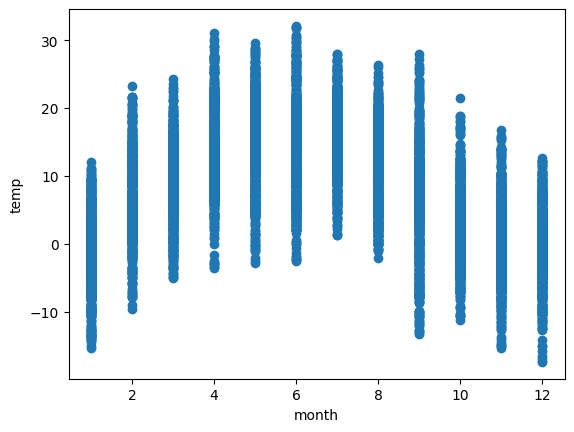

In [59]:
plt.scatter((df_training['datetime'].dt.month), df_training['temperature_C'])
plt.xlabel('month')
plt.ylabel("temp")
plt.show